In [1]:
import os

import chemiscope
import ipi
import numpy as np
from ase.visualize import view
from matplotlib import pyplot as plt
import nqetools as nqe
# This follows:
# https://github.com/i-pi/piqm2023-tutorial/blob/main/05-RPI/tutorial-4.ipynb

In [2]:
#UNITS:
invcm2au = 4.5563353e-06  #in i-PI unit_to_internal("frequency", "inversecm", 1.0)
kelvin2au = 3.1668152e-06


def get_freq_from_eigvals(eigvals):
    """Transforms eigenvalues in atomic units to frequencies in cm^-1"""
    freq_invcm = np.zeros(eigvals.shape)
    for i, eig in enumerate(eigvals):
        freq_invcm[i] = np.sign(eig) * np.absolute(eig) ** 0.5 / invcm2au
    return freq_invcm


# Paths
directory_opti = 'opti'
directory_phonon_react = 'phonon_react'
directory_ts = 'ts'
directory_phonon_ts = 'phonon_ts'
directory_instanton = 'instanton'

directory_opti_d = 'opti_d'
directory_phonon_react_d = 'phonon_react_d'
directory_ts_d = 'ts_d'
directory_phonon_ts_d = 'phonon_ts_d'

# Driver
driver_code = 'cbe'

# Values
temperature = 300.0
n_beads = 10
tol_energy = 5.0e-4
tol_force = 5.0e-4
tol_position = 1.0e-4
total_steps = 1000
optimizer = "cg"


In [3]:
atoms = nqe.read_ipi_xyz("react.xyz")[-1]
n_atoms = len(atoms)

atoms_ts = nqe.read_ipi_xyz("ts.xyz")[-1]
from ase.visualize import view


In [4]:
# Run minimization
output = nqe.run_optimise(directory_opti,
                          atoms,
                          driver=driver_code,
                          tol_energy=tol_energy,
                          tol_force=tol_force,
                          tol_position=tol_position,)
atoms_opti, output_data_opti, output_desc_opti = output

Running the minimisation with the driver: cbe


  J. Espinosa-Garcia and J. C. Corchado                                      
  Unpublished results, 1999.                                                 
                                                                             
                                                                             
                                                                             


   MAX. AND ACTUAL NO. OF EXCITED SURFACES:   0       0
   MAX. AND ACTUAL ORDER OF DERIVATIVES:      1       1

  The potential routine in POTLIB assumes a
  default labeling of the atoms.  The user has
  made the following selection of atomic labels:

               DEFAULT                         USER-SELECTED

  Atom  1 is       H                                   H 
  Atom  2 is       C                                   C 
  Atom  3 is       H                                   H 
  Atom  4 is       H                                   H 
  Atom  5 is

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


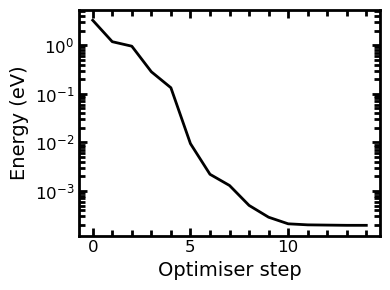

In [5]:
# Plot the energy of the minimisation
nqe.plot_step_energy(output_data_opti, save=False)

In [6]:
nqe.run_phonons(directory_phonon_react,
                atoms_opti,
                driver=driver_code,
                )

Running the phonons with the driver: cbe


  J. Espinosa-Garcia and J. C. Corchado                                      
  Unpublished results, 1999.                                                 
                                                                             
                                                                             
                                                                             


   MAX. AND ACTUAL NO. OF EXCITED SURFACES:   0       0
   MAX. AND ACTUAL ORDER OF DERIVATIVES:      1       1

  The potential routine in POTLIB assumes a
  default labeling of the atoms.  The user has
  made the following selection of atomic labels:

               DEFAULT                         USER-SELECTED

  Atom  1 is       H                                   H 
  Atom  2 is       C                                   C 
  Atom  3 is       H                                   H 
  Atom  4 is       H                                   H 
  Atom  5 is     

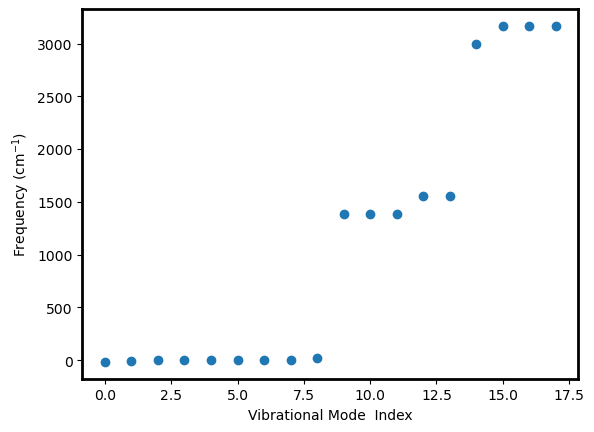

In [7]:
eigvals = np.genfromtxt(os.path.join(directory_phonon_react, 'phonon.phonons.eigval'))
fr = get_freq_from_eigvals(eigvals)

plt.plot(fr, 'o')
plt.xlabel('Vibrational Mode  Index')
plt.ylabel('Frequency (cm$^{-1}$)')
plt.show()

In [8]:
nqe.run_instanton_post_process(directory_phonon_react,
                               process_type='reactant',
                               temperature=temperature,
                               filter_list=n_atoms - 1)

Running the reactant thermo/instanton post-processing
Working directory: phonon_react
Running command:
python /home/louie/skunkworks/nqetools/nqetools/instanton_tools/postproc.py RESTART -t 300.0 -c reactant -n 1 -f 5
Thermo/Instanton post-processing complete



In [9]:
data = nqe.parse_react_thermo_data(directory_phonon_react)
print(data)

{'Qtras': 9.298, 'Qrot': 438.767, 'logQvib_rp': -20.517}


In [10]:
output = nqe.run_ts(directory_ts,
                    atoms_ts,
                    driver=driver_code,
                    tol_energy=tol_energy,
                    tol_force=tol_force,
                    tol_position=tol_position,)
atoms_ts, output_data_ts, output_desc_ts = output

Running the transition state search with the driver: cbe


  J. Espinosa-Garcia and J. C. Corchado                                      
  Unpublished results, 1999.                                                 
                                                                             
                                                                             
                                                                             


   MAX. AND ACTUAL NO. OF EXCITED SURFACES:   0       0
   MAX. AND ACTUAL ORDER OF DERIVATIVES:      1       1

  The potential routine in POTLIB assumes a
  default labeling of the atoms.  The user has
  made the following selection of atomic labels:

               DEFAULT                         USER-SELECTED

  Atom  1 is       H                                   H 
  Atom  2 is       C                                   C 
  Atom  3 is       H                                   H 
  Atom  4 is       H                                   H 
 

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


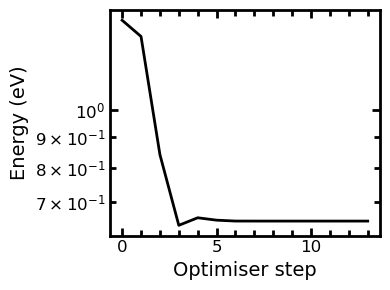

In [11]:
# Plot the energy of the minimisation
nqe.plot_step_energy(output_data_ts, save=False)

In [12]:
rate = nqe.calc_forward_rate(n_atoms, directory_ts, directory_phonon_react, temperature, 0.0)
print(rate)

Running the reactant thermo/instanton post-processing
Working directory: phonon_react
Running command:
python /home/louie/skunkworks/nqetools/nqetools/instanton_tools/postproc.py RESTART -t 300.0 -c reactant -n 1 -f 5
Thermo/Instanton post-processing complete

Running the TS thermo/instanton post-processing
Working directory: ts
Running command:
python /home/louie/skunkworks/nqetools/nqetools/instanton_tools/postproc.py RESTART -t 300.0 -c TS -n 1 -e 0.0
Thermo/Instanton post-processing complete

1.0618897441221483e-08


In [13]:
nqe.run_phonons(directory_phonon_ts,
                atoms_ts,
                driver=driver_code)

Running the phonons with the driver: cbe


  J. Espinosa-Garcia and J. C. Corchado                                      
  Unpublished results, 1999.                                                 
                                                                             
                                                                             
                                                                             


   MAX. AND ACTUAL NO. OF EXCITED SURFACES:   0       0
   MAX. AND ACTUAL ORDER OF DERIVATIVES:      1       1

  The potential routine in POTLIB assumes a
  default labeling of the atoms.  The user has
  made the following selection of atomic labels:

               DEFAULT                         USER-SELECTED

  Atom  1 is       H                                   H 
  Atom  2 is       C                                   C 
  Atom  3 is       H                                   H 
  Atom  4 is       H                                   H 
  Atom  5 is     

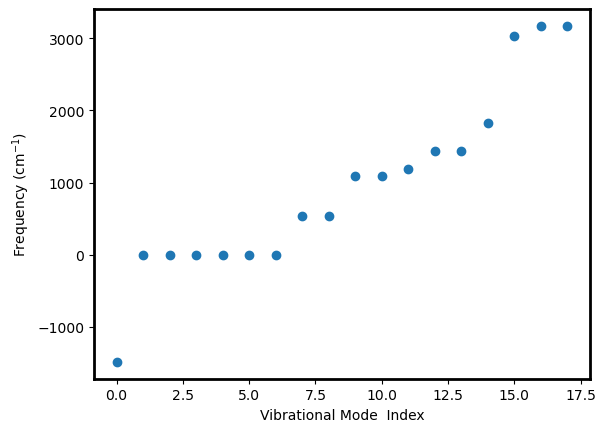

In [14]:
eigvals = np.genfromtxt(os.path.join(directory_phonon_ts, 'phonon.phonons.eigval'))
fr = get_freq_from_eigvals(eigvals)

plt.plot(fr, 'o')
plt.xlabel('Vibrational Mode  Index')
plt.ylabel('Frequency (cm$^{-1}$)')
plt.show()

In [15]:
# Run the instanton
nqe.run_instanton(directory_instanton,
                  atoms_ts,
                  directory_ts,
                  driver=driver_code,
                  n_beads=n_beads,
                  temperature=temperature,
                  tol_energy=tol_energy,
                  tol_force=tol_force,
                  tol_position=tol_position,)

Running the instanton with the driver: cbe


  J. Espinosa-Garcia and J. C. Corchado                                      
  Unpublished results, 1999.                                                 
                                                                             
                                                                             
                                                                             


   MAX. AND ACTUAL NO. OF EXCITED SURFACES:   0       0
   MAX. AND ACTUAL ORDER OF DERIVATIVES:      1       1

  The potential routine in POTLIB assumes a
  default labeling of the atoms.  The user has
  made the following selection of atomic labels:

               DEFAULT                         USER-SELECTED

  Atom  1 is       H                                   H 
  Atom  2 is       C                                   C 
  Atom  3 is       H                                   H 
  Atom  4 is       H                                   H 
  Atom  5 is   

In [16]:
nqe.calc_kappa_full(directory_ts,
                    directory_instanton,
                    temperature,
                    n_beads)

Running the TS thermo/instanton post-processing
Working directory: ts
Running command:
python /home/louie/skunkworks/nqetools/nqetools/instanton_tools/postproc.py RESTART -t 300.0 -c TS -n 1 -e 10
Thermo/Instanton post-processing complete

Running the instanton thermo/instanton post-processing
Working directory: instanton
Running command:
python /home/louie/skunkworks/nqetools/nqetools/instanton_tools/postproc.py RESTART -t 300.0 -c instanton -n 4 -e 10
Thermo/Instanton post-processing complete



18.4907941320064

In [17]:
# Converge over temperature
list_temperature = [100, 150, 200, 250, 300, 350, 400]
list_temperature = [200, 250, 300, 350, 400]
list_kappa = []
n_beads = 40

for temperature in list_temperature:
    print(f"Running with {temperature} K")
    nqe.run_instanton(directory_instanton,
                      atoms_ts,
                      directory_ts,
                      driver=driver_code,
                      n_beads=n_beads,
                      temperature=temperature,
                      tol_energy=tol_energy,
                          tol_force=tol_force,
                          tol_position=tol_position,)
    kappa = nqe.calc_kappa_full(directory_ts,
                                directory_instanton,
                                temperature,
                                n_beads=n_beads,
                                react_energy=0.0)
    list_kappa.append(kappa + 1)

Running with 200 K
Running the instanton with the driver: cbe


  J. Espinosa-Garcia and J. C. Corchado                                      
  Unpublished results, 1999.                                                 
                                                                             
                                                                             
                                                                             


   MAX. AND ACTUAL NO. OF EXCITED SURFACES:   0       0
   MAX. AND ACTUAL ORDER OF DERIVATIVES:      1       1

  The potential routine in POTLIB assumes a
  default labeling of the atoms.  The user has
  made the following selection of atomic labels:

               DEFAULT                         USER-SELECTED

  Atom  1 is       H                                   H 
  Atom  2 is       C                                   C 
  Atom  3 is       H                                   H 
  Atom  4 is       H                                  

[227.7062329754857, 21.408412936286094, 11.13019688539438, 1.0, 1.0]


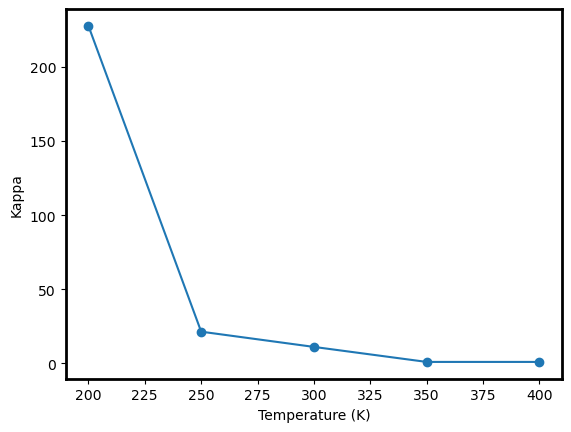

In [18]:
print(list_kappa)
plt.plot(list_temperature, list_kappa, 'o-')
plt.xlabel('Temperature (K)')
plt.ylabel('Kappa')
plt.show()

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


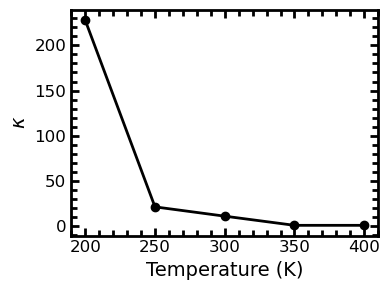

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


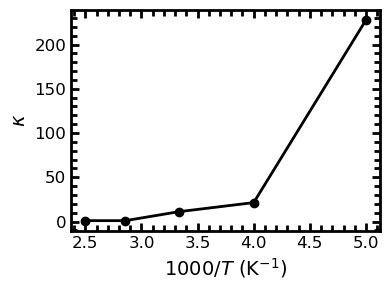

In [19]:
nqe.plot_kappa_temperature(list_temperature, list_kappa)
nqe.plot_kappa_temperature_inv(list_temperature, list_kappa)

In [20]:
rates = []
for temperature in list_temperature:
    output = nqe.run_ts(directory_ts,
                        atoms_ts,
                        driver=driver_code,
                        tol_energy=tol_energy,
                        tol_force=tol_force,
                        tol_position=tol_position,
                        total_steps=total_steps,
                        )

    atoms_ts, output_data_ts, _ = output

    rate = nqe.calc_forward_rate(n_atoms,
                                 directory_ts,
                                 directory_phonon_react,
                                 temperature,
                                 0.0)

    rates.append(rate)

Running the transition state search with the driver: cbe


  J. Espinosa-Garcia and J. C. Corchado                                      
  Unpublished results, 1999.                                                 
                                                                             
                                                                             
                                                                             


   MAX. AND ACTUAL NO. OF EXCITED SURFACES:   0       0
   MAX. AND ACTUAL ORDER OF DERIVATIVES:      1       1

  The potential routine in POTLIB assumes a
  default labeling of the atoms.  The user has
  made the following selection of atomic labels:

               DEFAULT                         USER-SELECTED

  Atom  1 is       H                                   H 
  Atom  2 is       C                                   C 
  Atom  3 is       H                                   H 
  Atom  4 is       H                                   H 
 

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


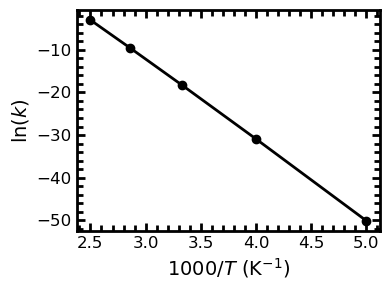

/home/louie/skunkworks/nqetools/nqetools/plotting.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


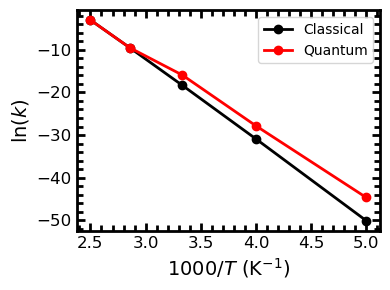

In [21]:
nqe.plot_arrhenius(list_temperature, rates)

rates_quantum = []
for i, rate in enumerate(rates):
    rates_quantum.append(rate * list_kappa[i])

nqe.plot_arrhenius_2(list_temperature, rates, rates_quantum)


In [ ]:
# Try and converge over beads
list_n_beads = [10, 20, 40, 60, 80]
list_kappa = []

for n_beads in list_n_beads:
    print(f"Running with {n_beads} beads")
    nqe.run_instanton(directory_instanton,
                      atoms_ts,
                      directory_ts,
                      driver=driver_code,
                      n_beads=n_beads,
                      temperature=temperature,
                      tol_energy=tol_energy,
                          tol_force=tol_force,
                          tol_position=tol_position,)
    kappa = nqe.calc_kappa_full(directory_ts,
                                directory_instanton,
                                temperature,
                                n_beads=n_beads,
                                react_energy=0.0,
                                )
    list_kappa.append(kappa)

In [ ]:
nqe.plot_bead_convergence(list_n_beads, list_kappa)

In [ ]:
# Classical KIE

# Run minimization
output = nqe.run_optimise(directory_opti_d,
                          atoms,
                          driver=driver_code,
                          deuterate=True,
                          tol_energy=tol_energy,
                          tol_force=tol_force,
                          tol_position=tol_position,
                          )
atoms_opti_d, output_data_opti_d, _ = output

# Plot the energy of the minimisation
nqe.plot_step_energy(output_data_opti_d, save=False)

nqe.run_phonons(directory_phonon_react_d,
                atoms_opti_d,
                driver=driver_code,
                deuterate=True
                )

eigvals = np.genfromtxt(os.path.join(directory_phonon_react_d, 'phonon.phonons.eigval'))
fr = get_freq_from_eigvals(eigvals)

plt.plot(fr, 'o')
plt.xlabel('Vibrational Mode  Index')
plt.ylabel('Frequency (cm$^{-1}$)')
plt.show()

nqe.run_instanton_post_process(directory_phonon_react_d,
                               process_type='reactant',
                               temperature=temperature,
                               filter_list=n_atoms - 1)

output = nqe.run_ts(directory_ts_d,
                    atoms_ts,
                    driver=driver_code,
                    tol_energy=tol_energy,
                    tol_force=tol_force,
                    tol_position=tol_position,
                    total_steps=total_steps,
                    deuterate=True,
                    )

atoms_ts_d, output_data_ts_d, _ = output

rate = nqe.calc_forward_rate(n_atoms,
                             directory_ts_d,
                             directory_phonon_react_d,
                             temperature,
                             0.0)
print(rate)
